In [1]:
from google.colab import files
uploaded = files.upload()

Saving insurance.csv to insurance.csv


In [2]:
# Celda 1 — Preparación de datos
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

df = pd.read_csv('insurance.csv')

# Convertir texto a números
df_model = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

X = df_model.drop('charges', axis=1)
y = df_model['charges']

# 80% entrenar, 20% testear
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Entrenamiento: {X_train.shape[0]} filas")
print(f"Test: {X_test.shape[0]} filas")

Entrenamiento: 1070 filas
Test: 268 filas


In [3]:
# Celda 2 — Entrenar modelo y métricas
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²:   {r2:.2f}  → el modelo explica el {r2*100:.0f}% de la variación en charges")
print(f"RMSE: ${rmse:,.0f}  → error promedio por persona")

R²:   0.78  → el modelo explica el 78% de la variación en charges
RMSE: $5,796  → error promedio por persona


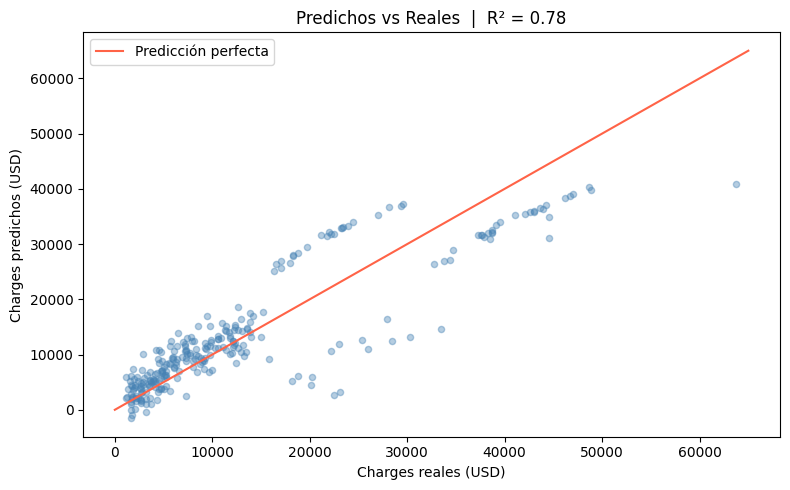

In [4]:
# Celda 3 — Predichos vs reales
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(y_test, y_pred, alpha=0.4, color='steelblue', s=20)
ax.plot([0, 65000], [0, 65000], color='tomato', linewidth=1.5, label='Predicción perfecta')

ax.set_xlabel('Charges reales (USD)')
ax.set_ylabel('Charges predichos (USD)')
ax.set_title(f'Predichos vs Reales  |  R² = {r2:.2f}')
ax.legend()
plt.tight_layout()
plt.show()

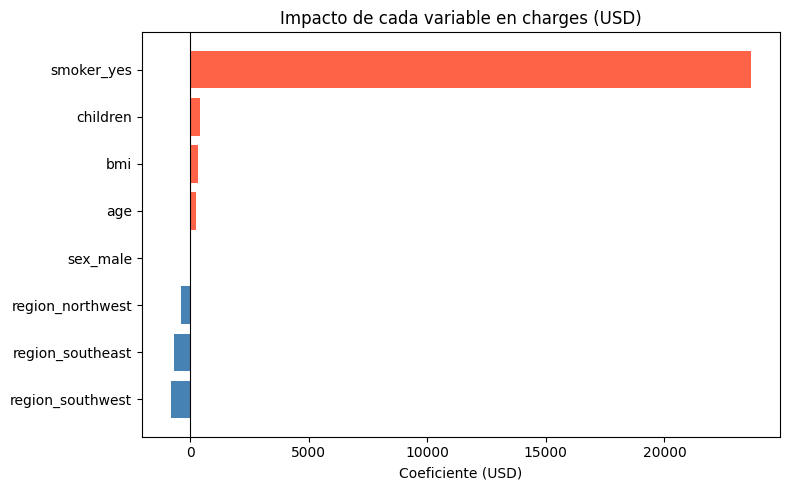

In [5]:
# Celda 4 — Importancia de variables
coef = pd.Series(model.coef_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['tomato' if c > 0 else 'steelblue' for c in coef]
ax.barh(coef.index, coef.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Impacto de cada variable en charges (USD)')
ax.set_xlabel('Coeficiente (USD)')
plt.tight_layout()
plt.show()